In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, date, time
import datetime as dt
from pandas import Series
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn import metrics
from sklearn.cluster import DBSCAN
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold
from sklearn.metrics import silhouette_score, davies_bouldin_score
import scipy.cluster.hierarchy as shc



import warnings

warnings.filterwarnings("ignore")

In [ ]:
customer_data = pd.read_csv('/content/data (1).csv', encoding='latin-1')
customer_data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
customer_data.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
customer_data.describe(include='O')

,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,541909,541909,540455,541909,541909
unique,25900,4070,4223,23260,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10/31/2011 14:41,United Kingdom
freq,1114,2313,2369,1114,495478


In [ ]:
customer_data.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
customer_data1 = customer_data.dropna()


In [ ]:
len(customer_data1[customer_data1['Quantity'] == 0])

0

In [ ]:
len(customer_data1[customer_data1['UnitPrice'] == 0])

40

In [ ]:
customer_data1 = (customer_data1[(customer_data1.UnitPrice != 0)])

customer_data1

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [ ]:
customer_data1['InvoiceNo'].str.replace('[0-9]', '' , regex=True).unique()

array(['', 'C'], dtype=object)

In [ ]:
customer_data1['InvoiceNo'].str.replace('[0-9]', '' , regex=True).value_counts()

,count
InvoiceNo,
,397884
C,8905


In [ ]:
display(customer_data1.loc[(customer_data1.Quantity<0)])

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom


In [ ]:
customer_data1 = customer_data1.drop(columns= ['Description'])

customer_data1.head(2)

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
product_dataset = customer_data1.copy()

product_dataset.head()

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
customer_dataS = customer_data1.copy()

customer_dataS.shape

(406789, 7)

In [ ]:
customer_dataS['Total_Price'] = customer_dataS['Quantity'] * customer_dataS['UnitPrice']

In [ ]:
customer_dataS = customer_dataS.drop(columns = ['Quantity','UnitPrice','Country'])

In [ ]:
display(customer_dataS.loc[(customer_dataS.Total_Price<0)])

,InvoiceNo,StockCode,InvoiceDate,CustomerID,Total_Price
141,C536379,D,12/1/2010 9:41,14527.0,-27.50
154,C536383,35004C,12/1/2010 9:49,15311.0,-4.65
235,C536391,22556,12/1/2010 10:24,17548.0,-19.80
236,C536391,21984,12/1/2010 10:24,17548.0,-6.96
237,C536391,21983,12/1/2010 10:24,17548.0,-6.96
...,...,...,...,...,...
540449,C581490,23144,12/9/2011 9:57,14397.0,-9.13
541541,C581499,M,12/9/2011 10:28,15498.0,-224.69
541715,C581568,21258,12/9/2011 11:57,15311.0,-54.75
541716,C581569,84978,12/9/2011 11:58,17315.0,-1.25


In [ ]:
customer_dataS['Cancelled_Order'] = customer_dataS['Total_Price'].map(lambda x: x < 0)

display(customer_dataS.loc[(customer_dataS.Total_Price<0)])

,InvoiceNo,StockCode,InvoiceDate,CustomerID,Total_Price,Cancelled_Order
141,C536379,D,12/1/2010 9:41,14527.0,-27.50,True
154,C536383,35004C,12/1/2010 9:49,15311.0,-4.65,True
235,C536391,22556,12/1/2010 10:24,17548.0,-19.80,True
236,C536391,21984,12/1/2010 10:24,17548.0,-6.96,True
237,C536391,21983,12/1/2010 10:24,17548.0,-6.96,True
...,...,...,...,...,...,...
540449,C581490,23144,12/9/2011 9:57,14397.0,-9.13,True
541541,C581499,M,12/9/2011 10:28,15498.0,-224.69,True
541715,C581568,21258,12/9/2011 11:57,15311.0,-54.75,True
541716,C581569,84978,12/9/2011 11:58,17315.0,-1.25,True


In [ ]:
customer_dataS['Cancelled_Order'] = customer_dataS['Cancelled_Order'].replace('False'== 0 , 'True'== -1)



display(customer_dataS.loc[(customer_dataS.Total_Price==0)])

,InvoiceNo,StockCode,InvoiceDate,CustomerID,Total_Price,Cancelled_Order


In [ ]:
customer_dataS['InvoiceDate'] = pd.to_datetime(customer_dataS['InvoiceDate'],

                            format ='mixed',dayfirst = 'bool')

customer_dataS['InvoiceDate'] = pd.to_datetime(customer_dataS['InvoiceDate'],format="%m.%d.%Y %I:%M:%S.%f %p" )

customer_dataS['InvoiceDate']

,InvoiceDate
0,2010-01-12 08:26:00
1,2010-01-12 08:26:00
2,2010-01-12 08:26:00
3,2010-01-12 08:26:00
4,2010-01-12 08:26:00
...,...
541904,2011-09-12 12:50:00
541905,2011-09-12 12:50:00
541906,2011-09-12 12:50:00
541907,2011-09-12 12:50:00


In [ ]:
df = pd.DataFrame(customer_dataS['InvoiceDate'])             #: pd.date_range('2016-1-1 10:00:00.123', periods=10, freq='5H')})

customer_dataS['Date_Invoice'] = df['InvoiceDate'].dt.date

customer_dataS['Time_Invoice'] = df['InvoiceDate'].dt.time

             #Added Date_Invoice  Time_Invoice columns, seperated from InvoiceDate

customer_dataS.head(2)

,InvoiceNo,StockCode,InvoiceDate,CustomerID,Total_Price,Cancelled_Order,Date_Invoice,Time_Invoice
0,536365,85123A,2010-01-12 08:26:00,17850.0,15.30,False,2010-01-12,08:26:00
1,536365,71053,2010-01-12 08:26:00,17850.0,20.34,False,2010-01-12,08:26:00


In [ ]:
customer_dataS = customer_dataS.drop(columns=['InvoiceDate','Time_Invoice'])

customer_dataS.head(2)

,InvoiceNo,StockCode,CustomerID,Total_Price,Cancelled_Order,Date_Invoice
0,536365,85123A,17850.0,15.30,False,2010-01-12
1,536365,71053,17850.0,20.34,False,2010-01-12


In [ ]:
dt.timedelta(1)

datetime.timedelta(days=1)

In [ ]:
pin_date = max(customer_dataS['Date_Invoice']) + dt.timedelta(1)

pin_date

datetime.date(2011, 12, 11)

In [ ]:
clustering_data = customer_dataS.groupby('CustomerID').agg({

    'Date_Invoice': lambda x: (pin_date - x.max()).days,

    'InvoiceNo': 'count',

    'Total_Price': 'sum',

    'Cancelled_Order' : 'sum'

})

clustering_data.head()

,Date_Invoice,InvoiceNo,Total_Price,Cancelled_Order
CustomerID,,,,
12346.0,327,2,0.00,1
12347.0,41,182,4310.00,0
12348.0,77,31,1797.24,0
12349.0,20,73,1757.55,0
12350.0,312,17,334.40,0


In [ ]:
clustering_data.rename(columns= {

    'Date_Invoice': 'DaysFreq',

    'InvoiceNo': 'PurchaseFreq',

    'Total_Price': 'TotalAmount',

    'Cancelled_Order': 'CancellationsFreq'

}, inplace=True)

clustering_data.head()

,DaysFreq,PurchaseFreq,TotalAmount,CancellationsFreq
CustomerID,,,,
12346.0,327,2,0.00,1
12347.0,41,182,4310.00,0
12348.0,77,31,1797.24,0
12349.0,20,73,1757.55,0
12350.0,312,17,334.40,0


In [ ]:
clustering_data = (clustering_data[(clustering_data.TotalAmount!= 0)])

clustering_data.shape

(4364, 4)

In [ ]:
clustering_data ['CancellationsFreq'] = clustering_data ['CancellationsFreq']/clustering_data ['PurchaseFreq'] * 100

clustering_data .head() #in percentage as how much percentage of purchase was returned.

,DaysFreq,PurchaseFreq,TotalAmount,CancellationsFreq
CustomerID,,,,
12347.0,41,182,4310.00,0.000000
12348.0,77,31,1797.24,0.000000
12349.0,20,73,1757.55,0.000000
12350.0,312,17,334.40,0.000000
12352.0,74,95,1545.41,10.526316


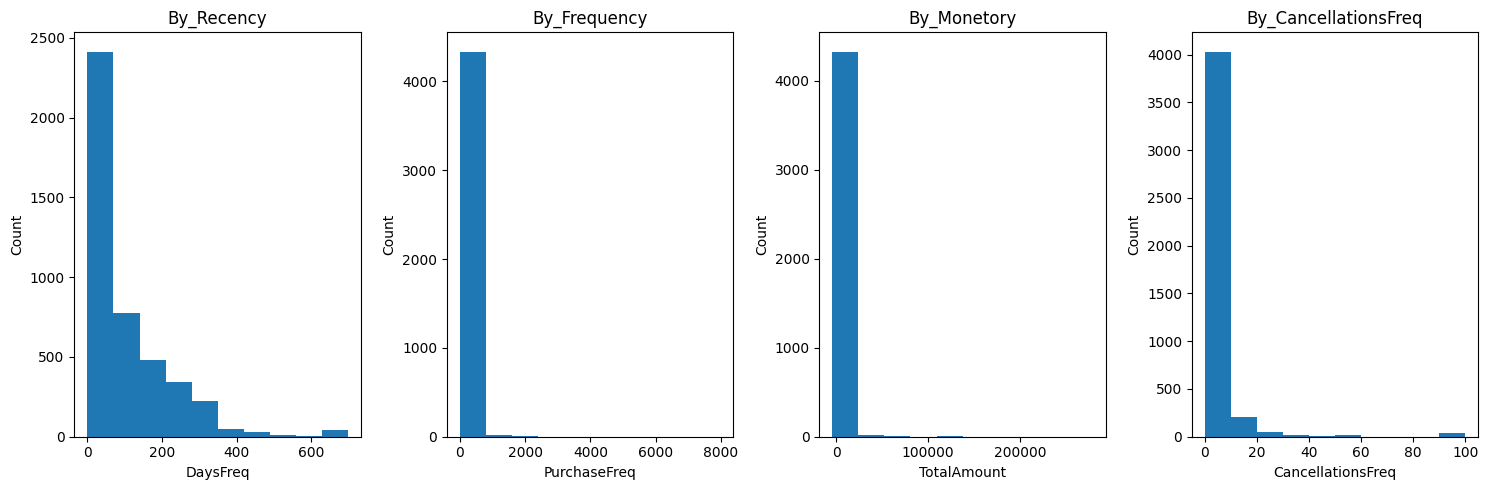

In [ ]:
plt.figure(figsize=(15,5))



plt.subplot(1,4,1)

plt.hist(clustering_data['DaysFreq'])         #, camp='rainbow'

plt.xlabel('DaysFreq')

plt.ylabel('Count')

plt.title('By_Recency')

plt.subplot(1,4,2)

plt.hist(clustering_data['PurchaseFreq'])         #, camp='rainbow'

plt.xlabel('PurchaseFreq')

plt.ylabel('Count')

plt.title('By_Frequency')

plt.subplot(1,4,3)

plt.hist(clustering_data['TotalAmount'])         #, camp='rainbow'

plt.xlabel('TotalAmount')

plt.ylabel('Count')

plt.title('By_Monetory')

plt.subplot(1,4,4)

plt.hist(clustering_data['CancellationsFreq'])         #, camp='rainbow'

plt.xlabel('CancellationsFreq')

plt.ylabel('Count')

plt.title('By_CancellationsFreq')


plt.tight_layout()

plt.show()

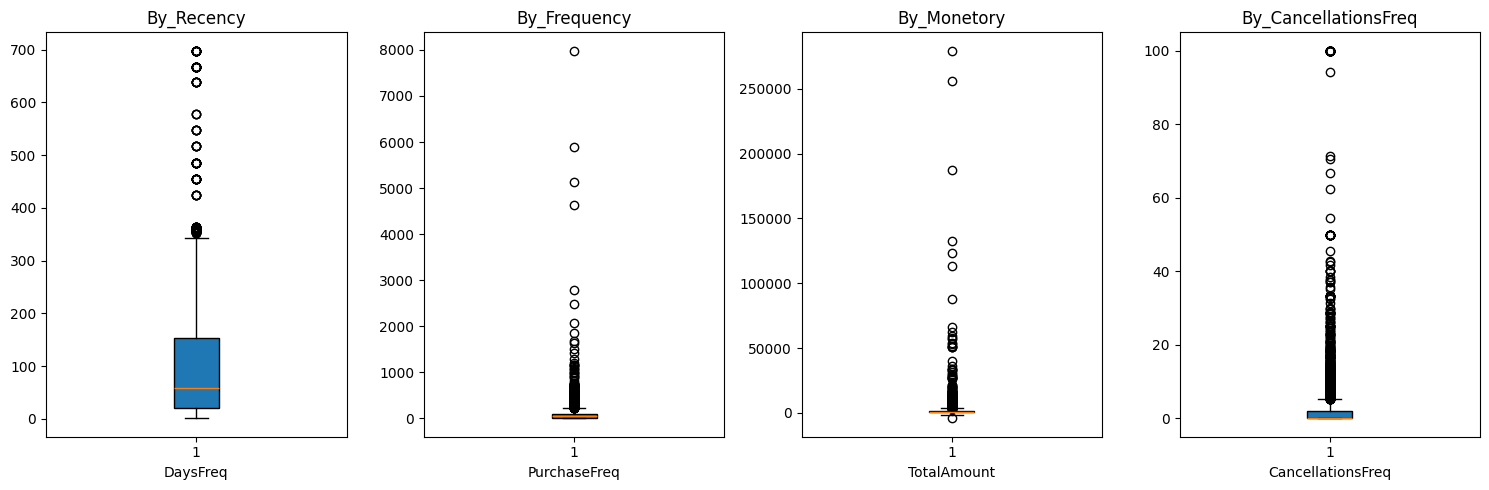

In [ ]:
plt.figure(figsize=(15,5))



plt.subplot(1,4,1)

plt.boxplot(clustering_data['DaysFreq'],  patch_artist=True)         #, camp='rainbow'

plt.xlabel('DaysFreq')

plt.title('By_Recency')

plt.subplot(1,4,2)

plt.boxplot(clustering_data['PurchaseFreq'],  patch_artist=True)         #, camp='rainbow'

plt.xlabel('PurchaseFreq')

plt.title('By_Frequency')



plt.subplot(1,4,3)

plt.boxplot(clustering_data['TotalAmount'],  patch_artist=True)         #, camp='rainbow'

plt.xlabel('TotalAmount')

plt.title('By_Monetory')





plt.subplot(1,4,4)

plt.boxplot(clustering_data['CancellationsFreq'], patch_artist=True)         #, camp='rainbow'

plt.xlabel('CancellationsFreq')

plt.title('By_CancellationsFreq')


plt.tight_layout()

plt.show()

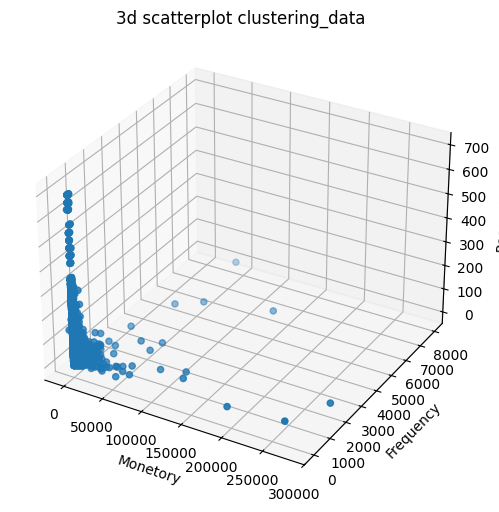

In [ ]:
fig = plt.figure(figsize=(6,6))



ax = fig.add_subplot(projection='3d')



scatter = ax.scatter(clustering_data['TotalAmount'],clustering_data['PurchaseFreq'],clustering_data['DaysFreq'])



ax.set_xlabel('Monetory')

ax.set_ylabel('Frequency')

ax.set_zlabel('Recancy')

ax.set_title('3d scatterplot clustering_data')



plt.show()

In [ ]:
m_q1 = clustering_data['TotalAmount'].quantile(0.25)   #25th percentile of total transformed_data set

m_q3 = clustering_data['TotalAmount'].quantile(0.75)    #3rd quartile,75th percentile of total transformed_data set



interquantile_range = m_q3 - m_q1



monetory_outliers = clustering_data[(clustering_data['TotalAmount']> (m_q3 + 1.5*interquantile_range)) | (clustering_data['TotalAmount']< (m_q1 - 1.5*interquantile_range))].copy()

monetory_outliers.describe()

,DaysFreq,PurchaseFreq,TotalAmount,CancellationsFreq
count,423.000000,423.000000,423.000000,423.000000
mean,27.732861,383.600473,11638.593144,3.500923
std,37.356005,640.560391,24254.291245,7.369163
min,1.000000,1.000000,-4287.630000,0.000000
25%,7.000000,154.500000,4321.590000,0.472493
50%,16.000000,260.000000,5739.460000,1.639344
75%,27.000000,408.000000,9199.510000,4.016211
max,306.000000,7983.000000,279489.020000,100.000000


In [ ]:
f_q1 = clustering_data['PurchaseFreq'].quantile(0.25)   #25th percentile of total transformed_data set

f_q3 = clustering_data['PurchaseFreq'].quantile(0.75)    #3rd quartile,75th percentile of total transformed_data set



interquantile_range = f_q3 - f_q1



frequency_outliers = clustering_data[(clustering_data['PurchaseFreq']> (f_q3 + 1.5*interquantile_range)) | (clustering_data['PurchaseFreq']< (f_q1 - 1.5*interquantile_range))].copy()



frequency_outliers.describe()

,DaysFreq,PurchaseFreq,TotalAmount,CancellationsFreq
count,380.000000,380.000000,380.000000,380.000000
mean,25.192105,493.442105,10058.544921,2.324030
std,30.455338,646.662721,25499.087945,3.861076
min,1.000000,230.000000,576.300000,0.000000
25%,7.000000,277.750000,2608.942500,0.181516
50%,16.000000,344.000000,4561.905000,1.003197
75%,28.000000,474.000000,7318.080000,2.729730
max,236.000000,7983.000000,279489.020000,32.517483


In [ ]:
monetory_outliers.shape

(423, 4)

In [ ]:
frequency_outliers.shape

(380, 4)

In [ ]:
not_outliers = clustering_data[(~clustering_data.index.isin(monetory_outliers.index)) & (~clustering_data.index.isin(frequency_outliers.index))]

not_outliers.describe()

,DaysFreq,PurchaseFreq,TotalAmount,CancellationsFreq
count,3799.000000,3799.000000,3799.000000,3799.000000
mean,112.734141,51.238484,806.528835,3.154138
std,117.530048,48.739293,772.200804,10.969555
min,1.000000,1.000000,-1592.490000,0.000000
25%,26.000000,15.000000,255.650000,0.000000
50%,70.000000,33.000000,537.060000,0.000000
75%,172.000000,73.000000,1106.465000,1.639344
max,698.000000,229.000000,3580.130000,100.000000


In [ ]:
not_outliers.shape

(3799, 4)

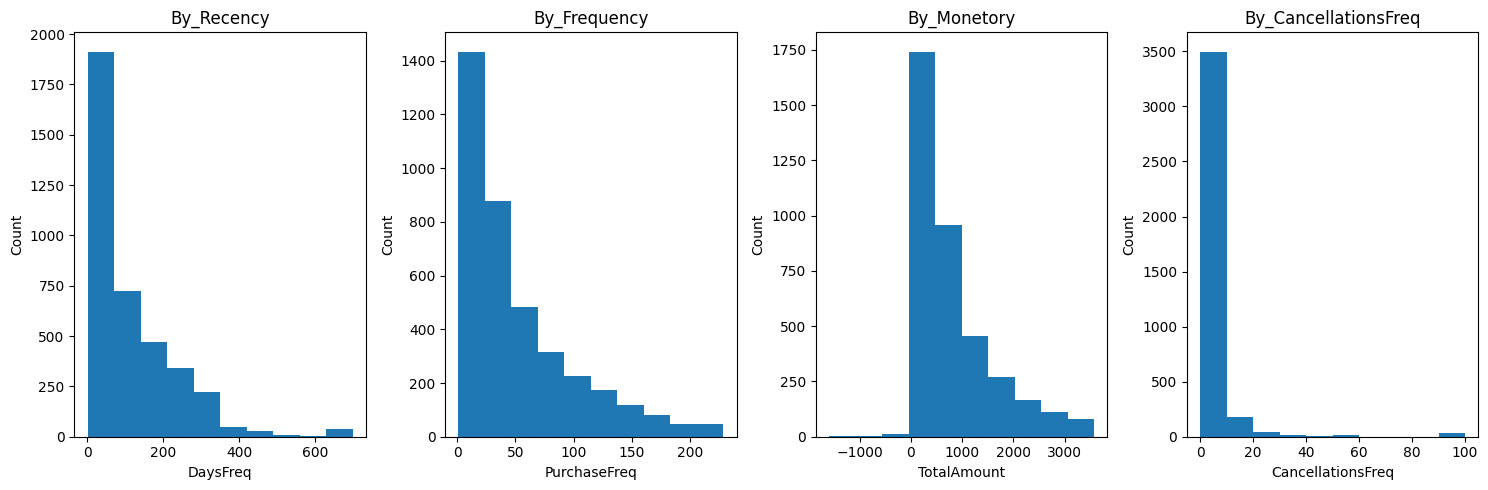

In [ ]:
plt.figure(figsize=(15,5))



plt.subplot(1,4,1)

plt.hist(not_outliers['DaysFreq'])         #, camp='rainbow'

plt.xlabel('DaysFreq')

plt.ylabel('Count')

plt.title('By_Recency')

plt.subplot(1,4,2)

plt.hist(not_outliers['PurchaseFreq'])         #, camp='rainbow'

plt.xlabel('PurchaseFreq')

plt.ylabel('Count')

plt.title('By_Frequency')

plt.subplot(1,4,3)

plt.hist(not_outliers['TotalAmount'])         #, camp='rainbow'

plt.xlabel('TotalAmount')

plt.ylabel('Count')

plt.title('By_Monetory')

plt.subplot(1,4,4)

plt.hist(not_outliers['CancellationsFreq'])         #, camp='rainbow'

plt.xlabel('CancellationsFreq')

plt.ylabel('Count')

plt.title('By_CancellationsFreq')



# Adjust subplot spacing

plt.tight_layout()

plt.show()

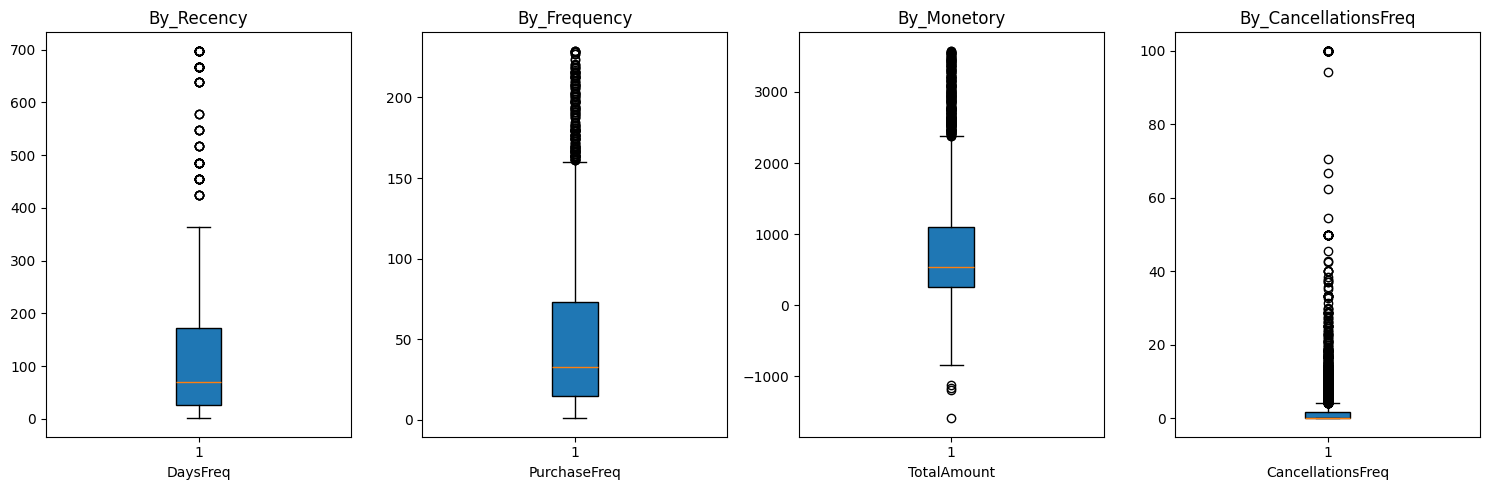

In [ ]:
plt.figure(figsize=(15,5))



plt.subplot(1,4,1)

plt.boxplot(not_outliers['DaysFreq'],  patch_artist=True)         #, camp='rainbow'

plt.xlabel('DaysFreq')

plt.title('By_Recency')


plt.subplot(1,4,2)

plt.boxplot(not_outliers['PurchaseFreq'],  patch_artist=True)         #, camp='rainbow'

plt.xlabel('PurchaseFreq')

plt.title('By_Frequency')

plt.subplot(1,4,3)

plt.boxplot(not_outliers['TotalAmount'],  patch_artist=True)         #, camp='rainbow'

plt.xlabel('TotalAmount')

plt.title('By_Monetory')

plt.subplot(1,4,4)

plt.boxplot(not_outliers['CancellationsFreq'], patch_artist=True)         #, camp='rainbow'

plt.xlabel('CancellationsFreq')

plt.title('By_CancellationsFreq')



# Adjust subplot spacing

plt.tight_layout()

plt.show()

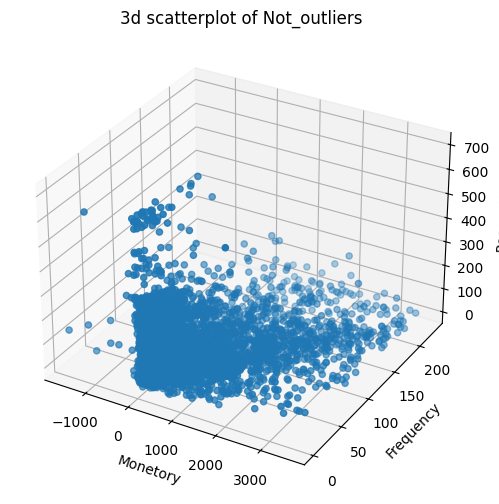

In [ ]:
 fig = plt.figure(figsize=(6,6))



ax = fig.add_subplot(projection='3d')



scatter = ax.scatter(not_outliers['TotalAmount'], not_outliers['PurchaseFreq'], not_outliers['DaysFreq'])



ax.set_xlabel('Monetory')

ax.set_ylabel('Frequency')

ax.set_zlabel('Recancy')

ax.set_title('3d scatterplot of Not_outliers')



plt.show()

In [ ]:
scaler = StandardScaler()

data_scaled = scaler.fit_transform(not_outliers)



data_scaled

array([[-0.30408262, -0.41529425,  1.2831398 , -0.28757349],
       [-0.78912882,  0.44654691,  1.23173448, -0.28757349],
       [ 1.69566927, -0.70257464, -0.6114873 , -0.28757349],
       ...,
       [-0.91677256, -0.90777491, -0.93991662, -0.28757349],
       [-0.15941971, -0.78465475, -0.81586519,  0.41376033],
       [-0.95081089,  0.38498683,  1.33499842, -0.28757349]])

In [ ]:
scaled_dataframe = pd.DataFrame(data_scaled, index=not_outliers.index ,columns=('DaysFreq','PurchaseFreq','TotalAmount','CancellationsFreq'))



scaled_dataframe.shape

(3799, 4)

In [ ]:
scaled_dataframe

,DaysFreq,PurchaseFreq,TotalAmount,CancellationsFreq
CustomerID,,,,
12348.0,-0.304083,-0.415294,1.283140,-0.287573
12349.0,-0.789129,0.446547,1.231734,-0.287573
12350.0,1.695669,-0.702575,-0.611487,-0.287573
12352.0,-0.329611,0.897988,0.956977,0.672146
12353.0,0.793654,-0.969335,-0.929322,-0.287573
...,...,...,...,...
18278.0,-0.321102,-0.866735,-0.819362,-0.287573
18280.0,0.410722,-0.846215,-0.810685,-0.287573
18281.0,-0.916773,-0.907775,-0.939917,-0.287573


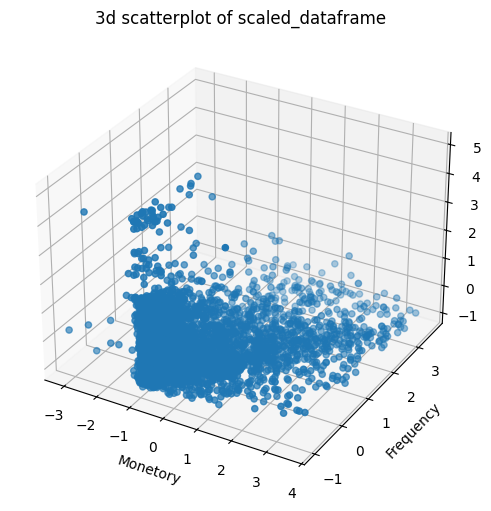

In [ ]:
fig = plt.figure(figsize=(6,6))



ax = fig.add_subplot(projection='3d')



scatter = ax.scatter(scaled_dataframe['TotalAmount'], scaled_dataframe['PurchaseFreq'], scaled_dataframe['DaysFreq'])



ax.set_xlabel('Monetory')

ax.set_ylabel('Frequency')

ax.set_zlabel('Recancy')



ax.set_title('3d scatterplot of scaled_dataframe')

plt.show()

In [ ]:
scaled_dataframe

,DaysFreq,PurchaseFreq,TotalAmount,CancellationsFreq
CustomerID,,,,
12348.0,-0.304083,-0.415294,1.283140,-0.287573
12349.0,-0.789129,0.446547,1.231734,-0.287573
12350.0,1.695669,-0.702575,-0.611487,-0.287573
12352.0,-0.329611,0.897988,0.956977,0.672146
12353.0,0.793654,-0.969335,-0.929322,-0.287573
...,...,...,...,...
18278.0,-0.321102,-0.866735,-0.819362,-0.287573
18280.0,0.410722,-0.846215,-0.810685,-0.287573
18281.0,-0.916773,-0.907775,-0.939917,-0.287573


In [ ]:
inertia_values = []

silhouette_scores = []

K_range = range(2, 11)  # You can adjust the range as needed



for K in K_range:

    kmeans = KMeans(n_clusters=K, max_iter=300, random_state=42)         #max_iter=300

    kmeans.fit(scaled_dataframe)



    # Inertia (within-cluster sum of squares)

    inertia_values.append(kmeans.inertia_)

    # Silhouette Score

    silhouette = silhouette_score(scaled_dataframe, kmeans.labels_)

    silhouette_scores.append(silhouette)

In [ ]:
print('silhouette_scores : ', silhouette_scores)

silhouette_scores :  [np.float64(0.39536129323606334), np.float64(0.4267630204271382), np.float64(0.37836102396569987), np.float64(0.33292095871360644), np.float64(0.3413676108999941), np.float64(0.3523465309167142), np.float64(0.3147945913100481), np.float64(0.2810155195120438), np.float64(0.2978412198075863)]


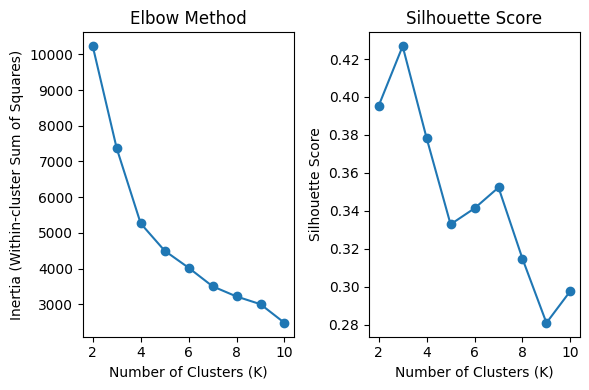

In [ ]:
plt.figure(figsize=(6, 4))



plt.subplot(1, 2, 1)

plt.plot(K_range, inertia_values, marker='o', linestyle='-')      #marker='o',

plt.xlabel('Number of Clusters (K)')

plt.ylabel('Inertia (Within-cluster Sum of Squares)')

plt.title('Elbow Method')

#plt.show()

plt.subplot(1, 2, 2)

plt.plot(K_range, silhouette_scores, marker='o', linestyle='-')

plt.xlabel('Number of Clusters (K)')

plt.ylabel('Silhouette Score')

plt.title('Silhouette Score')



plt.tight_layout()

plt.show()

In [ ]:
pca = PCA(n_components=2)      #how any column we want to creat

In [ ]:
df_pca = pca.fit_transform(scaled_dataframe)

In [ ]:
data_pca_df = pd.DataFrame(df_pca)

data_pca_df.columns = ['P1','P2']

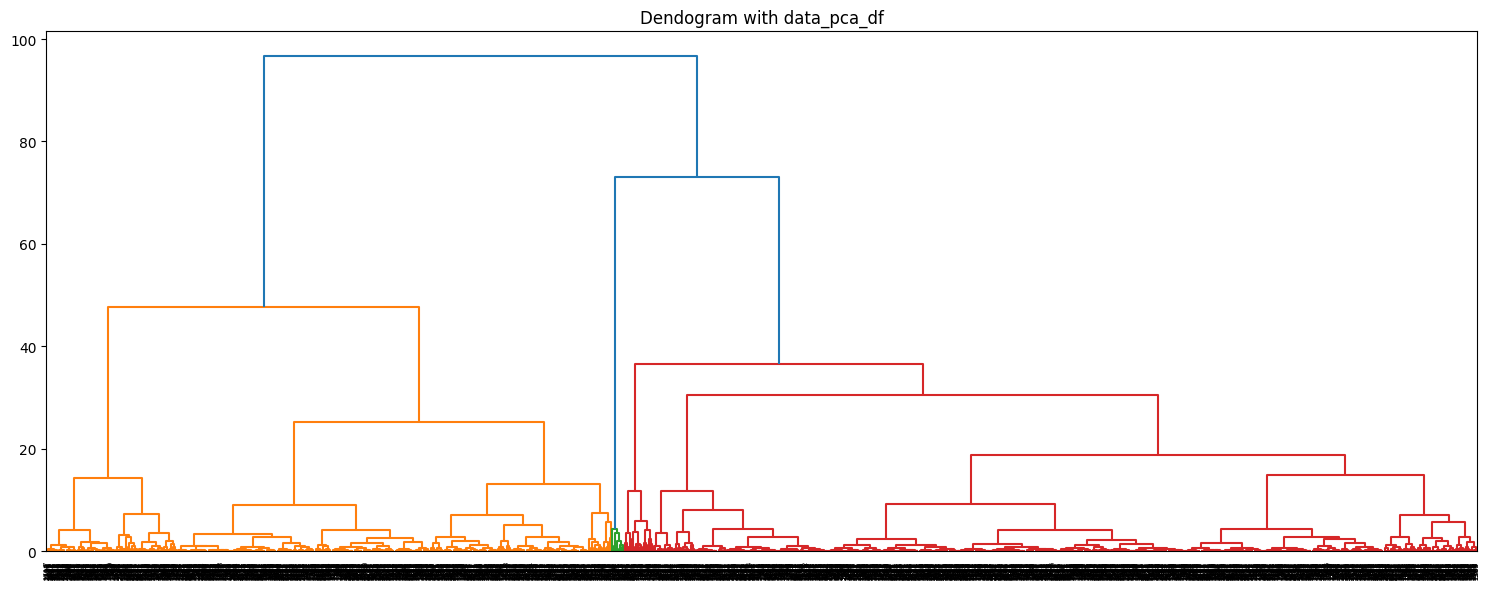

In [ ]:
plt.figure(figsize=(15,6), layout='tight')

plt.title('Dendogram with data_pca_df')



dendogram = shc.dendrogram((shc.linkage(data_pca_df, method='ward')))

In [ ]:
scaler = StandardScaler()

DB_scaled = scaler.fit_transform(not_outliers)

In [ ]:
# Initialize DBSCAN model

# eps: The maximum distance between two samples for them to be considered as in the same neighborhood.

# min_samples: The number of samples in a neighborhood for a point to be considered as a core point.

dbscan = DBSCAN(eps=0.3, min_samples=10)

dbscan

DBSCAN(eps=0.3, min_samples=10)

In [ ]:
# Fit the model

labels = dbscan.fit_predict(DB_scaled)


In [ ]:
unique_labels = set(labels)

unique_labels

{np.int64(-1),
 np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5)}

In [ ]:
# Perform K-means clustering

# Assuming X is your dataset

kmeans = KMeans(n_clusters=4, max_iter=1000, random_state=42)

kmeans.fit(scaled_dataframe)



# Get cluster labels

labels = kmeans.labels_



# Inertia (Within-cluster sum of squares)

inertia = kmeans.inertia_



# Silhouette Score

sil_score = silhouette_score(scaled_dataframe , labels)



print(f"Inertia (Within-cluster sum of squares): {inertia}")

print(f"Silhouette Score: {sil_score}")

Inertia (Within-cluster sum of squares): 5265.668301561204
Silhouette Score: 0.37836102396569987


In [ ]:
scaled_dataframe['cluster4'] = kmeans.fit_predict(scaled_dataframe)

not_outliers['cluster4'] = kmeans.fit_predict(scaled_dataframe)

In [ ]:
not_outliers['cluster4'].value_counts()

,count
cluster4,
1,2012
0,924
2,811
3,52


In [ ]:
not_outliers.head()

,DaysFreq,PurchaseFreq,TotalAmount,CancellationsFreq,cluster4
CustomerID,,,,,
12348.0,77,31,1797.24,0.000000,1
12349.0,20,73,1757.55,0.000000,2
12350.0,312,17,334.40,0.000000,0
12352.0,74,95,1545.41,10.526316,2
12353.0,206,4,89.00,0.000000,0


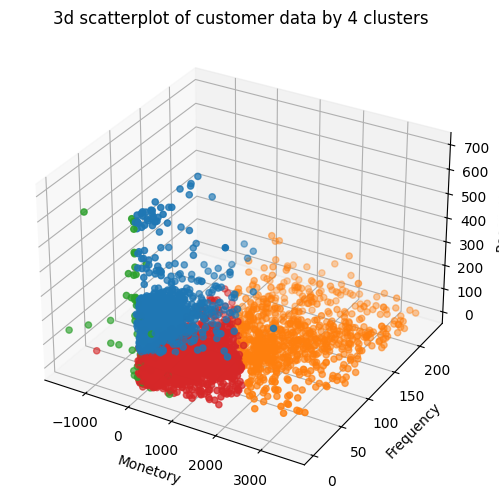

In [ ]:
cluster_colors = {0:'#1f77b4',  #blue

                  1:'#ff7f0e',   #orange

                  2:'#2ca02c',   #green

                  3:'#d62728'}   #red



colors = scaled_dataframe['cluster4'].map(cluster_colors)



fig = plt.figure(figsize=(6,6))



ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(not_outliers['TotalAmount'],

                     not_outliers['PurchaseFreq'],

                     not_outliers['DaysFreq'],

                     c=colors)



ax.set_xlabel('Monetory')

ax.set_ylabel('Frequency')

ax.set_zlabel('Recancy')



ax.set_title('3d scatterplot of customer data by 4 clusters')

plt.show()


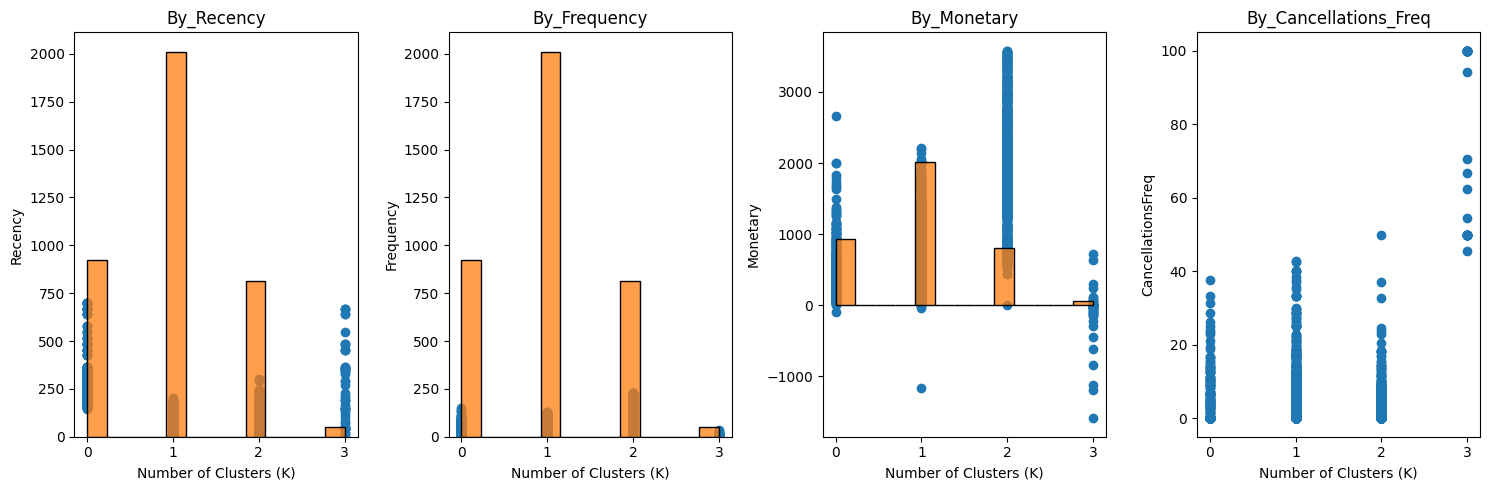

In [ ]:
plt.figure(figsize=(15,5))





plt.subplot(1,4,1)

plt.scatter(not_outliers['cluster4'], not_outliers['DaysFreq'])         #, camp='rainbow'

plt.xlabel('Number of Clusters (K)')

plt.ylabel('Recency')

plt.title('By_Recency')

plt.subplot(1,4,1)

sns.histplot(data=not_outliers, x='cluster4' )

plt.subplot(1,4,2)

plt.scatter(not_outliers['cluster4'], not_outliers['PurchaseFreq'])         #, camp='rainbow'

plt.xlabel('Number of Clusters (K)')

plt.ylabel('Frequency')

plt.title('By_Frequency')

plt.subplot(1,4,2)

sns.histplot(data=not_outliers, x='cluster4' )



plt.subplot(1,4,3)

plt.scatter(not_outliers['cluster4'], not_outliers['TotalAmount'])         #, camp='rainbow'

plt.xlabel('Number of Clusters (K)')

plt.ylabel('Monetary')

plt.title('By_Monetary')

plt.subplot(1,4,3)

sns.histplot(data=not_outliers, x='cluster4' )



plt.subplot(1,4,4)

plt.scatter(not_outliers['cluster4'], not_outliers['CancellationsFreq'])         #, camp='rainbow'

plt.xlabel('Number of Clusters (K)')

plt.ylabel('CancellationsFreq')

plt.title('By_Cancellations_Freq')

plt.tight_layout()

plt.show()


In [ ]:
import pickle

In [ ]:
pickle.dump(kmeans,open( 'kmeansCustSegPrediction.pkl','wb'))

In [ ]:
kmeans = pickle.load(open('kmeansCustSegPrediction.pkl','rb'))

In [ ]:
product_dataset.head(2)        # we reated a copy of cleaned dataset for future referance., that copy we are using here

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
product_dataset['StockCode'].value_counts()

,count
StockCode,
85123A,2077
22423,1904
85099B,1662
84879,1418
47566,1415
...,...
17028J,1
84795C,1
90025F,1


In [ ]:
product_dataset['StockCode'] = product_dataset['StockCode'].astype('str')

product_dataset[product_dataset['StockCode'].str.match("^\\d{5}$") == False]        #typing regex pattern for 5 digit numbers., to return everything else other than 5 digit codes

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
2,536365,84406B,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
45,536370,POST,3,12/1/2010 8:45,18.00,12583.0,France
...,...,...,...,...,...,...,...
541778,581578,84997C,8,12/9/2011 12:16,4.15,12713.0,Germany
541809,581579,85099C,10,12/9/2011 12:19,1.79,17581.0,United Kingdom
541838,581580,84993A,2,12/9/2011 12:20,0.42,12748.0,United Kingdom
541844,581580,85049A,1,12/9/2011 12:20,1.25,12748.0,United Kingdom


In [ ]:
product_dataset['StockCode'] = product_dataset['StockCode'].astype('str')

product_dataset[(product_dataset['StockCode'].str.match("^\\d{5}$") == False)

& (product_dataset['StockCode'].str.match("^\\d{5}[a-zA-Z]+$") == False)]['StockCode'].unique()

array(['POST', 'D', 'C2', 'M', 'BANK CHARGES', 'PADS', 'DOT', 'CRUK'],
      dtype=object)

In [ ]:
product_dataset[product_dataset['StockCode'].str.contains('^[POST, D, C2, M, BANK CHARGES, PADS, DOT, CRUK]')]

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
5,536365,22752,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
10,536367,22745,6,12/1/2010 8:34,2.10,13047.0,United Kingdom
...,...,...,...,...,...,...,...
541904,581587,22613,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,4,12/9/2011 12:50,4.15,12680.0,France


In [ ]:
product_dataset[product_dataset['StockCode'].str.contains('^POST')] #POSTAGE,Discount ,CARRIAGE,Manual ,Bank Charges ,PADS TO MATCH ALL CUSHIONS ,DOTCOM POSTAGE,CRUK Commission

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
45,536370,POST,3,12/1/2010 8:45,18.0,12583.0,France
386,536403,POST,1,12/1/2010 11:27,15.0,12791.0,Netherlands
1123,536527,POST,1,12/1/2010 13:04,18.0,12662.0,Germany
5073,536840,POST,1,12/2/2010 18:27,18.0,12738.0,Germany
5258,536852,POST,1,12/3/2010 9:51,18.0,12686.0,France
...,...,...,...,...,...,...,...
541198,581493,POST,1,12/9/2011 10:10,15.0,12423.0,Belgium
541216,581494,POST,2,12/9/2011 10:13,18.0,12518.0,Germany
541730,581570,POST,1,12/9/2011 11:59,18.0,12662.0,Germany
541767,581574,POST,2,12/9/2011 12:09,18.0,12526.0,Germany


In [ ]:
df = pd.DataFrame()



# append columns to an empty DataFrame

df['Stockcode'] = ['POST', 'D', 'C2', 'M', 'BANK CHARGES', 'PADS', 'DOT', 'CRUK']

df['Count'] = [1196 ,77,134,459,12,3,16,16]

df['Description'] = ['POSTAGE','Discount','CARRIAGE','Manual' ,'Bank Charges','PADS TO MATCH ALL CUSHIONS' ,'DOTCOM POSTAGE','CRUK Commission']

df['Action'] = ['Exclude From Clustering','Exclude From Clustering','Exclude From Clustering','Exclude From Clustering','Exclude From Clustering','Include in Clustering','Exclude From Clustering','Exclude From Clustering']

df

,Stockcode,Count,Description,Action
0,POST,1196,POSTAGE,Exclude From Clustering
1,D,77,Discount,Exclude From Clustering
2,C2,134,CARRIAGE,Exclude From Clustering
3,M,459,Manual,Exclude From Clustering
4,BANK CHARGES,12,Bank Charges,Exclude From Clustering
5,PADS,3,PADS TO MATCH ALL CUSHIONS,Include in Clustering
6,DOT,16,DOTCOM POSTAGE,Exclude From Clustering
7,CRUK,16,CRUK Commission,Exclude From Clustering


In [ ]:
product_dataset1 = product_dataset.copy()

In [ ]:
product_dataset1['StockCode'] = product_dataset1['StockCode'].astype('str')



Mask = (

    (product_dataset1['StockCode'].str.match("^\\d{5}$") == True)

    | (product_dataset1['StockCode'].str.match("^\\d{5}[a-zA-Z]+$") == True)

    | (product_dataset1['StockCode'].str.match("^PADS") == True)

)

product_dataset1 = product_dataset1[Mask]



product_dataset1

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...
541904,581587,22613,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,4,12/9/2011 12:50,4.15,12680.0,France


In [ ]:
product_dataset1['Total_Price'] = product_dataset1['Quantity']*product_dataset1['UnitPrice']

product_dataset1.sort_index()

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_Price
0,536365,85123A,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...
541904,581587,22613,12,12/9/2011 12:50,0.85,12680.0,France,10.20
541905,581587,22899,6,12/9/2011 12:50,2.10,12680.0,France,12.60
541906,581587,23254,4,12/9/2011 12:50,4.15,12680.0,France,16.60
541907,581587,23255,4,12/9/2011 12:50,4.15,12680.0,France,16.60


In [ ]:
transformed_data = product_dataset1.groupby('StockCode').agg({

    #'Date_Invoice': lambda x: (pin_date - x.max()).days,

    'CustomerID' : 'count',

    'InvoiceNo': 'count',

    'Quantity' : 'sum',

    'Total_Price': 'sum'

})

transformed_data.head()

,CustomerID,InvoiceNo,Quantity,Total_Price
StockCode,,,,
10002,49,49,823,699.55
10080,21,21,291,114.41
10120,30,30,193,40.53
10123C,3,3,5,3.25
10124A,5,5,16,6.72


In [ ]:
transformed_data .rename(columns= {

        'InvoiceNo': 'Popularity',

        'Quantity' : 'Sold_Units',

        'Total_Price': 'Monetary'

}, inplace=True)

transformed_data = transformed_data.sort_values('Popularity', ascending=False)

transformed_data.head()

,CustomerID,Popularity,Sold_Units,Monetary
StockCode,,,,
85123A,2077,2077,34204,93979.20
22423,1904,1904,11545,132870.40
85099B,1662,1662,45066,83236.76
84879,1418,1418,35314,56499.22
47566,1415,1415,15023,67687.53


In [ ]:
transformed_data['R_Popularity'] = transformed_data['Popularity'].rank(method='dense', na_option='top', pct=True)

transformed_data['R_Sold_Units'] = transformed_data['Sold_Units'].rank(method='dense', na_option='top', pct=True)

transformed_data['R_Monetary'] = transformed_data['Monetary'].rank(method='dense', na_option='top', pct=True)


In [ ]:
#display(transformed_data.loc[(transformed_data.Popularity>1000)]

Cleaned_df = transformed_data.drop(columns=['Popularity','Sold_Units','Monetary'])

#Cleaned_df.head()

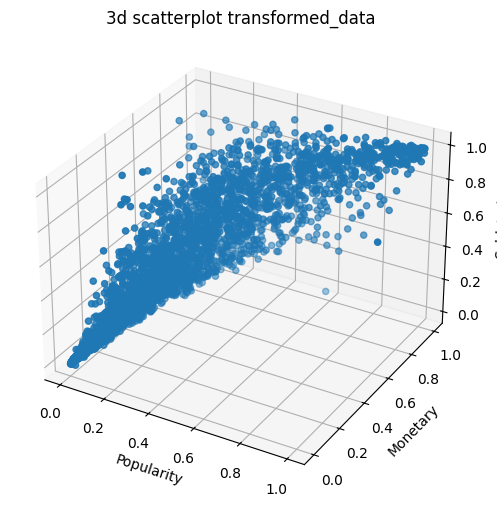

In [ ]:
fig = plt.figure(figsize=(6,6))



ax = fig.add_subplot(projection='3d')



scatter = ax.scatter(Cleaned_df['R_Popularity'],Cleaned_df['R_Monetary'], Cleaned_df['R_Sold_Units'])



ax.set_xlabel('Popularity')

ax.set_ylabel('Monetary')

ax.set_zlabel('Sold_Units')

ax.set_title('3d scatterplot transformed_data')



plt.show()

In [ ]:
Popularity = range(1, 5) #[4, 3, 2, 1]

R_Popularity = pd.qcut(Cleaned_df['R_Popularity'], q=4, labels=Popularity)

Monetary	 = range(1, 5) # [1, 2, 3, 4]

R_Monetary	 = pd.qcut(Cleaned_df['R_Monetary'], q=4, labels=Monetary)

Sold_Units = range(1,5)

R_Sold_Units= pd.qcut(Cleaned_df['R_Sold_Units'], q=4, labels=Sold_Units)



Cleaned_df['Popularity'] = R_Popularity.values

Cleaned_df['Monetary'] = R_Monetary.values

Cleaned_df['Sold_Units'] = R_Sold_Units.values

Cleaned_df.head()

,CustomerID,R_Popularity,R_Sold_Units,R_Monetary,Popularity,Monetary,Sold_Units
StockCode,,,,,,,
85123A,2077,1.000000,0.997723,0.999702,4,4,4
22423,1904,0.998134,0.970973,1.000000,4,4,4
85099B,1662,0.996269,0.998862,0.999403,4,4,4
84879,1418,0.994403,0.998293,0.998806,4,4,4
47566,1415,0.992537,0.986340,0.999105,4,4,4


In [ ]:
product_Recommandation = Cleaned_df.drop(columns=['Monetary','Sold_Units'])

product_Recommandation

,CustomerID,R_Popularity,R_Sold_Units,R_Monetary,Popularity
StockCode,,,,,
85123A,2077,1.000000,0.997723,0.999702,4
22423,1904,0.998134,0.970973,1.000000,4
85099B,1662,0.996269,0.998862,0.999403,4
84879,1418,0.994403,0.998293,0.998806,4
47566,1415,0.992537,0.986340,0.999105,4
...,...,...,...,...,...
90214O,1,0.001866,0.013090,0.017010,1
37330,1,0.001866,0.009676,0.013130,1
37351,1,0.001866,0.008537,0.010445,1


In [ ]:
Most_Popular_prod = product_Recommandation[product_Recommandation['Popularity']>2]

Most_Popular_prod['Popularity'].value_counts()

,count
Popularity,
3,916
4,915
2,0
1,0


In [ ]:
You_May_Also_Like = product_Recommandation[product_Recommandation['Popularity']==2]

You_May_Also_Like['Popularity'].value_counts()

,count
Popularity,
2,920
1,0
3,0
4,0


In [ ]:
product_dataset1 = product_dataset1.set_index('StockCode')

In [ ]:
final  = product_dataset1[(product_dataset1.index.isin(product_Recommandation.index))]

final['Promotion_product'] = product_Recommandation['Popularity']



final = final.reset_index()

final.head()

,StockCode,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_Price,Promotion_product
0,85123A,536365,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30,4
1,71053,536365,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,4
2,84406B,536365,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00,4
3,84029G,536365,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,4
4,84029E,536365,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,4


In [ ]:
final = final.set_index('CustomerID')

final

,StockCode,InvoiceNo,Quantity,InvoiceDate,UnitPrice,Country,Total_Price,Promotion_product
CustomerID,,,,,,,,
17850.0,85123A,536365,6,12/1/2010 8:26,2.55,United Kingdom,15.30,4
17850.0,71053,536365,6,12/1/2010 8:26,3.39,United Kingdom,20.34,4
17850.0,84406B,536365,8,12/1/2010 8:26,2.75,United Kingdom,22.00,4
17850.0,84029G,536365,6,12/1/2010 8:26,3.39,United Kingdom,20.34,4
17850.0,84029E,536365,6,12/1/2010 8:26,3.39,United Kingdom,20.34,4
...,...,...,...,...,...,...,...,...
12680.0,22613,581587,12,12/9/2011 12:50,0.85,France,10.20,3
12680.0,22899,581587,6,12/9/2011 12:50,2.10,France,12.60,4
12680.0,23254,581587,4,12/9/2011 12:50,4.15,France,16.60,4


In [ ]:
overlap_data = (monetory_outliers.index.intersection(frequency_outliers.index))

# overlap_data these customers are in both moneytory as well as frequency outliers.

monetory_only_outliers = monetory_outliers.drop(overlap_data) #monetory_only_outliers.shape

frequency_only_outliers = frequency_outliers.drop(overlap_data) #frequency_only_outliers.shape

monetory_and_frq_outliers =  monetory_outliers.loc[overlap_data]



monetory_and_frq_outliers['Customer_Segment'] = -1

monetory_only_outliers['Customer_Segment'] = -2

frequency_only_outliers['Customer_Segment'] = -3



outliers_dataset = pd.concat([monetory_and_frq_outliers, monetory_only_outliers, frequency_only_outliers])

outliers_dataset.head()

,DaysFreq,PurchaseFreq,TotalAmount,CancellationsFreq,Customer_Segment
CustomerID,,,,,
12359.0,10,254,6245.53,2.362205,-1
12362.0,13,274,5154.58,2.919708,-1
12415.0,26,776,123725.45,7.989691,-1
12428.0,27,300,7877.20,2.000000,-1
12431.0,3,239,6416.39,1.673640,-1


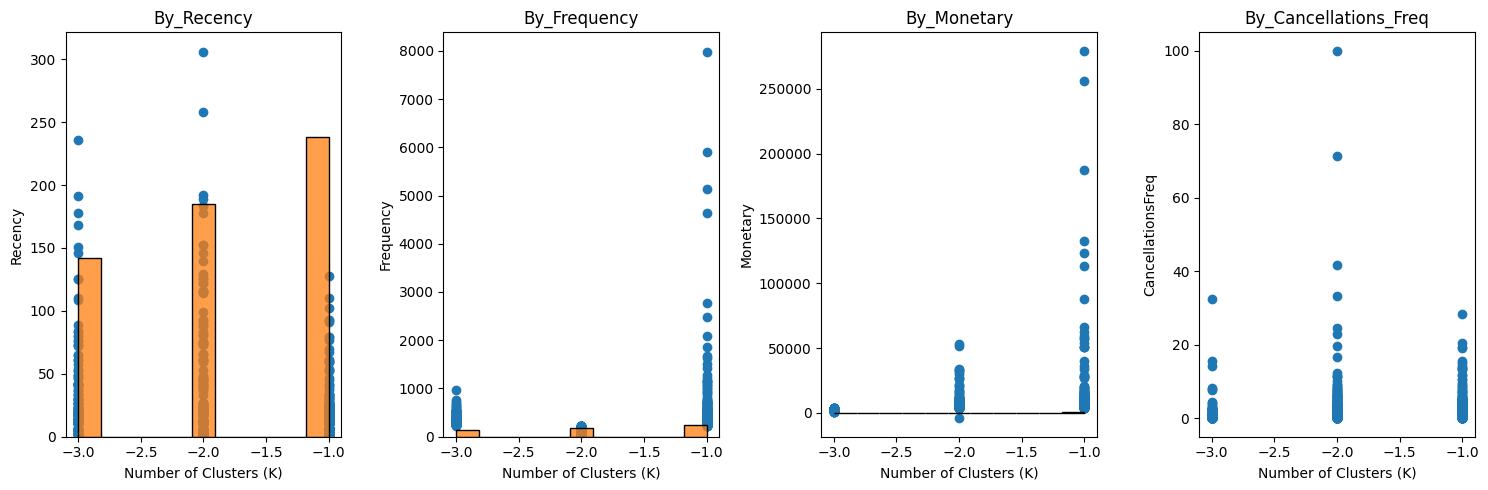

In [ ]:
plt.figure(figsize=(15,5))





plt.subplot(1,4,1)

plt.scatter(outliers_dataset['Customer_Segment'], outliers_dataset['DaysFreq'])         #, camp='rainbow'

plt.xlabel('Number of Clusters (K)')

plt.ylabel('Recency')

plt.title('By_Recency')

plt.subplot(1,4,1)

sns.histplot(data=outliers_dataset, x='Customer_Segment' )

plt.subplot(1,4,2)

plt.scatter(outliers_dataset['Customer_Segment'], outliers_dataset['PurchaseFreq'])         #, camp='rainbow'

plt.xlabel('Number of Clusters (K)')

plt.ylabel('Frequency')

plt.title('By_Frequency')

plt.subplot(1,4,2)

sns.histplot(data=outliers_dataset, x='Customer_Segment' )

plt.subplot(1,4,3)

plt.scatter(outliers_dataset['Customer_Segment'], outliers_dataset['TotalAmount'])         #, camp='rainbow'

plt.xlabel('Number of Clusters (K)')

plt.ylabel('Monetary')

plt.title('By_Monetary')

plt.subplot(1,4,3)

sns.histplot(data=outliers_dataset, x='Customer_Segment' )



plt.subplot(1,4,4)

plt.scatter(outliers_dataset['Customer_Segment'], outliers_dataset['CancellationsFreq'])         #, camp='rainbow'

plt.xlabel('Number of Clusters (K)')

plt.ylabel('CancellationsFreq')

plt.title('By_Cancellations_Freq')

plt.tight_layout()

plt.show()

In [ ]:
final1  = clustering_data[(clustering_data.index.isin(outliers_dataset.index))]

final1['Customer_Segment'] = outliers_dataset['Customer_Segment']

final1.head()


,DaysFreq,PurchaseFreq,TotalAmount,CancellationsFreq,Customer_Segment
CustomerID,,,,,
12347.0,41,182,4310.00,0.000000,-2
12357.0,183,131,6207.67,0.000000,-2
12359.0,10,254,6245.53,2.362205,-1
12362.0,13,274,5154.58,2.919708,-1
12378.0,306,219,4008.62,0.000000,-2


In [ ]:
final2  = clustering_data[(clustering_data.index.isin(not_outliers.index))]

final2['Customer_Segment'] = not_outliers['cluster4']

final2.head()


,DaysFreq,PurchaseFreq,TotalAmount,CancellationsFreq,Customer_Segment
CustomerID,,,,,
12348.0,77,31,1797.24,0.000000,1
12349.0,20,73,1757.55,0.000000,2
12350.0,312,17,334.40,0.000000,0
12352.0,74,95,1545.41,10.526316,2
12353.0,206,4,89.00,0.000000,0


In [ ]:
df = pd.concat([final1, final2])

df.head()

,DaysFreq,PurchaseFreq,TotalAmount,CancellationsFreq,Customer_Segment
CustomerID,,,,,
12347.0,41,182,4310.00,0.000000,-2
12357.0,183,131,6207.67,0.000000,-2
12359.0,10,254,6245.53,2.362205,-1
12362.0,13,274,5154.58,2.919708,-1
12378.0,306,219,4008.62,0.000000,-2


In [ ]:
final5 =  clustering_data[(clustering_data.index.isin(df.index))]

final5['Customer_Segment'] = df['Customer_Segment']

final5['TotalAmount'] = df['TotalAmount']

final5['CancellationsFreq'] = df['CancellationsFreq']

final5.head()

,DaysFreq,PurchaseFreq,TotalAmount,CancellationsFreq,Customer_Segment
CustomerID,,,,,
12347.0,41,182,4310.00,0.000000,-2
12348.0,77,31,1797.24,0.000000,1
12349.0,20,73,1757.55,0.000000,2
12350.0,312,17,334.40,0.000000,0
12352.0,74,95,1545.41,10.526316,2


In [ ]:
final.head(1)

,StockCode,InvoiceNo,Quantity,InvoiceDate,UnitPrice,Country,Total_Price,Promotion_product
CustomerID,,,,,,,,
17850.0,85123A,536365,6,12/1/2010 8:26,2.55,United Kingdom,15.3,4


In [ ]:
new_dataset = final[(final.index.isin(final5.index))]

In [ ]:
#new_dataset['Stockcode'] = final['StockCode']

new_dataset['Customer_Segment'] = final5['Customer_Segment']

new_dataset['TotalAmount'] = final5['TotalAmount']

new_dataset['CancellationsFreq'] = final5['CancellationsFreq']

new_dataset['Recency'] = final5['DaysFreq']

new_dataset['PurchaseFreq'] = final5['PurchaseFreq']



new_dataset

,StockCode,InvoiceNo,Quantity,InvoiceDate,UnitPrice,Country,Total_Price,Promotion_product,Customer_Segment,TotalAmount,CancellationsFreq,Recency,PurchaseFreq
CustomerID,,,,,,,,,,,,,
17850.0,85123A,536365,6,12/1/2010 8:26,2.55,United Kingdom,15.30,4,-1,5288.63,4.807692,70,312
17850.0,71053,536365,6,12/1/2010 8:26,3.39,United Kingdom,20.34,4,-1,5288.63,4.807692,70,312
17850.0,84406B,536365,8,12/1/2010 8:26,2.75,United Kingdom,22.00,4,-1,5288.63,4.807692,70,312
17850.0,84029G,536365,6,12/1/2010 8:26,3.39,United Kingdom,20.34,4,-1,5288.63,4.807692,70,312
17850.0,84029E,536365,6,12/1/2010 8:26,3.39,United Kingdom,20.34,4,-1,5288.63,4.807692,70,312
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12680.0,22613,581587,12,12/9/2011 12:50,0.85,France,10.20,3,1,862.81,0.000000,32,52
12680.0,22899,581587,6,12/9/2011 12:50,2.10,France,12.60,4,1,862.81,0.000000,32,52
12680.0,23254,581587,4,12/9/2011 12:50,4.15,France,16.60,4,1,862.81,0.000000,32,52


In [ ]:
new_dataset = new_dataset.reset_index()


In [ ]:
new_dataset.columns

Index(['CustomerID', 'StockCode', 'InvoiceNo', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'Country', 'Total_Price', 'Promotion_product',
       'Customer_Segment', 'TotalAmount', 'CancellationsFreq', 'Recency',
       'PurchaseFreq'],
      dtype='object')

In [ ]:
# we are adding lebles for each of the Customer Segment.

cluster_labels = {

    0: "RETAIN",

    1: "RE-ENGAGE",

    2: "NURTURE",

    3: "REWARD",

    -1: "PAMPER",

    -2: "UPSELL",

    -3: "DELIGHT"

}

In [ ]:
new_dataset["Customer_Segment"] = new_dataset["Customer_Segment"].map(cluster_labels)



new_dataset.head()

,CustomerID,StockCode,InvoiceNo,Quantity,InvoiceDate,UnitPrice,Country,Total_Price,Promotion_product,Customer_Segment,TotalAmount,CancellationsFreq,Recency,PurchaseFreq
0,17850.0,85123A,536365,6,12/1/2010 8:26,2.55,United Kingdom,15.30,4,PAMPER,5288.63,4.807692,70,312
1,17850.0,71053,536365,6,12/1/2010 8:26,3.39,United Kingdom,20.34,4,PAMPER,5288.63,4.807692,70,312
2,17850.0,84406B,536365,8,12/1/2010 8:26,2.75,United Kingdom,22.00,4,PAMPER,5288.63,4.807692,70,312
3,17850.0,84029G,536365,6,12/1/2010 8:26,3.39,United Kingdom,20.34,4,PAMPER,5288.63,4.807692,70,312
4,17850.0,84029E,536365,6,12/1/2010 8:26,3.39,United Kingdom,20.34,4,PAMPER,5288.63,4.807692,70,312


In [ ]:
#new_dataset['InvoiceDate'].



new_dataset['InvoiceDate'] = pd.to_datetime(new_dataset['InvoiceDate'],

                            format ='mixed',dayfirst = 'bool')

new_dataset['InvoiceDate'] = pd.to_datetime(new_dataset['InvoiceDate'],format="%m.%d.%Y %I:%M:%S.%f %p" )

new_dataset['InvoiceDate']

,InvoiceDate
0,2010-01-12 08:26:00
1,2010-01-12 08:26:00
2,2010-01-12 08:26:00
3,2010-01-12 08:26:00
4,2010-01-12 08:26:00
...,...
404805,2011-09-12 12:50:00
404806,2011-09-12 12:50:00
404807,2011-09-12 12:50:00
404808,2011-09-12 12:50:00


In [ ]:
df1 = pd.DataFrame(new_dataset['InvoiceDate'])             #: pd.date_range('2016-1-1 10:00:00.123', periods=10, freq='5H')})

new_dataset['InvoiceDate'] = df1['InvoiceDate'].dt.date

new_dataset

,CustomerID,StockCode,InvoiceNo,Quantity,InvoiceDate,UnitPrice,Country,Total_Price,Promotion_product,Customer_Segment,TotalAmount,CancellationsFreq,Recency,PurchaseFreq
0,17850.0,85123A,536365,6,2010-01-12,2.55,United Kingdom,15.30,4,PAMPER,5288.63,4.807692,70,312
1,17850.0,71053,536365,6,2010-01-12,3.39,United Kingdom,20.34,4,PAMPER,5288.63,4.807692,70,312
2,17850.0,84406B,536365,8,2010-01-12,2.75,United Kingdom,22.00,4,PAMPER,5288.63,4.807692,70,312
3,17850.0,84029G,536365,6,2010-01-12,3.39,United Kingdom,20.34,4,PAMPER,5288.63,4.807692,70,312
4,17850.0,84029E,536365,6,2010-01-12,3.39,United Kingdom,20.34,4,PAMPER,5288.63,4.807692,70,312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404805,12680.0,22613,581587,12,2011-09-12,0.85,France,10.20,3,RE-ENGAGE,862.81,0.000000,32,52
404806,12680.0,22899,581587,6,2011-09-12,2.10,France,12.60,4,RE-ENGAGE,862.81,0.000000,32,52
404807,12680.0,23254,581587,4,2011-09-12,4.15,France,16.60,4,RE-ENGAGE,862.81,0.000000,32,52
404808,12680.0,23255,581587,4,2011-09-12,4.15,France,16.60,4,RE-ENGAGE,862.81,0.000000,32,52


In [ ]:
prediction_dataset = pd.DataFrame()

prediction_dataset['InvoiceNo']  = new_dataset['InvoiceNo']

prediction_dataset['CustomerID'] = new_dataset['CustomerID']

prediction_dataset['InvoiceDate'] = new_dataset['InvoiceDate']

prediction_dataset['StockCode'] = new_dataset['StockCode']

prediction_dataset['TotalAmount'] = new_dataset['TotalAmount']

prediction_dataset['CancellationsFreq'] = new_dataset['CancellationsFreq']

prediction_dataset['UnitPrice'] = new_dataset['UnitPrice']

prediction_dataset['Quantity'] = new_dataset['Quantity']

prediction_dataset['Country'] = new_dataset['Country']

prediction_dataset['Customer_Segment'] = new_dataset['Customer_Segment']

prediction_dataset['Promotion_product'] = new_dataset['Promotion_product']

prediction_dataset['Recency'] = new_dataset['Recency']

prediction_dataset['PurchaseFreq']  = new_dataset['PurchaseFreq']





#InvoiceDate

prediction_dataset

,InvoiceNo,CustomerID,InvoiceDate,StockCode,TotalAmount,CancellationsFreq,UnitPrice,Quantity,Country,Customer_Segment,Promotion_product,Recency,PurchaseFreq
0,536365,17850.0,2010-01-12,85123A,5288.63,4.807692,2.55,6,United Kingdom,PAMPER,4,70,312
1,536365,17850.0,2010-01-12,71053,5288.63,4.807692,3.39,6,United Kingdom,PAMPER,4,70,312
2,536365,17850.0,2010-01-12,84406B,5288.63,4.807692,2.75,8,United Kingdom,PAMPER,4,70,312
3,536365,17850.0,2010-01-12,84029G,5288.63,4.807692,3.39,6,United Kingdom,PAMPER,4,70,312
4,536365,17850.0,2010-01-12,84029E,5288.63,4.807692,3.39,6,United Kingdom,PAMPER,4,70,312
...,...,...,...,...,...,...,...,...,...,...,...,...,...
404805,581587,12680.0,2011-09-12,22613,862.81,0.000000,0.85,12,France,RE-ENGAGE,3,32,52
404806,581587,12680.0,2011-09-12,22899,862.81,0.000000,2.10,6,France,RE-ENGAGE,4,32,52
404807,581587,12680.0,2011-09-12,23254,862.81,0.000000,4.15,4,France,RE-ENGAGE,4,32,52
404808,581587,12680.0,2011-09-12,23255,862.81,0.000000,4.15,4,France,RE-ENGAGE,4,32,52


In [ ]:
prediction_dataset.to_excel('2Prediction_dataset.xlsx')


In [ ]:
 df["Customer_Segment"] = df["Customer_Segment"].map(cluster_labels)

df.head()

,DaysFreq,PurchaseFreq,TotalAmount,CancellationsFreq,Customer_Segment
CustomerID,,,,,
12347.0,41,182,4310.00,0.000000,UPSELL
12357.0,183,131,6207.67,0.000000,UPSELL
12359.0,10,254,6245.53,2.362205,PAMPER
12362.0,13,274,5154.58,2.919708,PAMPER
12378.0,306,219,4008.62,0.000000,UPSELL


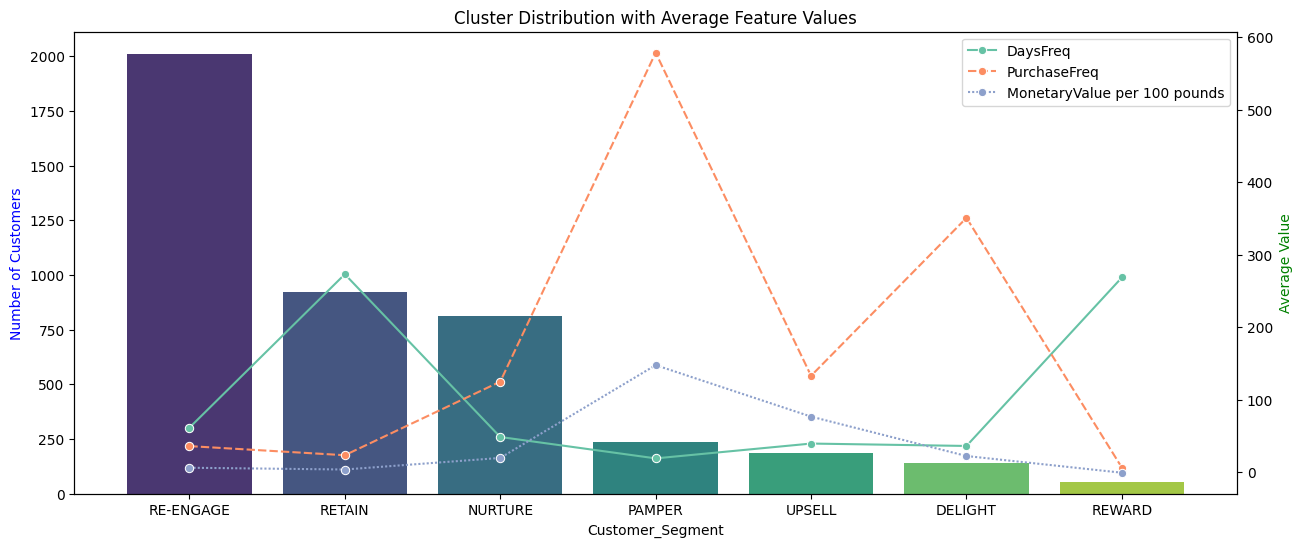

In [ ]:
cluster_counts = df["Customer_Segment"].value_counts()



df["MonetaryValue per 100 pounds"] = df["TotalAmount"] / 100.00

feature_means = df.groupby('Customer_Segment')[['DaysFreq', 'PurchaseFreq','MonetaryValue per 100 pounds']].mean()





fig, ax1 = plt.subplots(figsize=(15,6))



sns.barplot(x = cluster_counts.index, y = cluster_counts.values, hue_order = cluster_counts.index, palette='viridis')

ax1.set_ylabel('Number of Customers', color='b')

ax1.set_title('Cluster Distribution with Average Feature Values')


ax2 = ax1.twinx()



sns.lineplot(data=feature_means, ax=ax2, palette='Set2', marker='o')

ax2.set_ylabel('Average Value', color='g')



plt.savefig("Cluster_Distribution_withAverage_FeatureValues.png", format="png", bbox_inches="tight")

plt.show()
